# 03 — Price Forecasting
**PanganTrace AI** — Prediksi Harga 7 Hari (Prophet + SMA)

Notebook ini melatih model forecasting harga komoditas.

In [7]:
import sys
sys.path.insert(0, '../src')
sys.path.insert(0, '../data/synthetic')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Data

In [2]:
from generate_prices import generate_prices
prices_path = generate_prices(days=90, output_dir='../data/synthetic')
df = pd.read_csv(prices_path)
df['recorded_at'] = pd.to_datetime(df['recorded_at'])

# Filter satu komoditas dan provinsi untuk demo
df_beras = df[(df['commodity_id']=='beras_premium') & (df['province']=='Jawa Timur')].copy()
df_beras = df_beras.sort_values('recorded_at')
print(f'Beras Premium - Jawa Timur: {len(df_beras)} data points')

Generated 8100 price records (247 anomalies, 3.0%) -> ../data/synthetic\prices.csv
Beras Premium - Jawa Timur: 90 data points


## 2. Train Forecaster

In [3]:
from price_model import PriceForecaster

forecaster = PriceForecaster(forecast_days=7)
metrics = forecaster.train(df_beras, test_days=14)

print(f'\nTrain: {metrics["train_size"]} samples, Test: {metrics["test_size"]} samples')
print(f'Features: {metrics["n_features"]}')


Price model trained -- MAE: Rp 6,017, RMSE: Rp 6,620, MAPE: 9.95%

Train: 62 samples, Test: 14 samples
Features: 32


## 3. Generate Forecast

In [8]:
forecast = forecaster.predict(df_beras)
print(f"Model: {forecast['model']}")
print(f"Forecast days: {forecast['forecast_days']}")
for p in forecast['predictions']:
    print(f"  {p['date']}: Rp {p['predicted_price']:,} "
          f"(range: {p['lower_bound']:,}-{p['upper_bound']:,}, "
          f"confidence: {p['confidence']}%)")


Model: gradient_boosting
Forecast days: 7
  2026-04-29: Rp 52,958 (range: 50,544-55,372, confidence: 94.5%)
  2026-04-30: Rp 53,351 (range: 48,966-57,736, confidence: 91.0%)
  2026-05-01: Rp 54,312 (range: 47,964-60,660, confidence: 87.5%)
  2026-05-02: Rp 51,509 (range: 43,336-59,682, confidence: 84.0%)
  2026-05-03: Rp 51,337 (range: 40,423-62,252, confidence: 80.5%)
  2026-05-04: Rp 51,947 (range: 38,193-65,701, confidence: 77.0%)
  2026-05-05: Rp 52,105 (range: 35,690-68,521, confidence: 73.5%)


## 4. Visualize

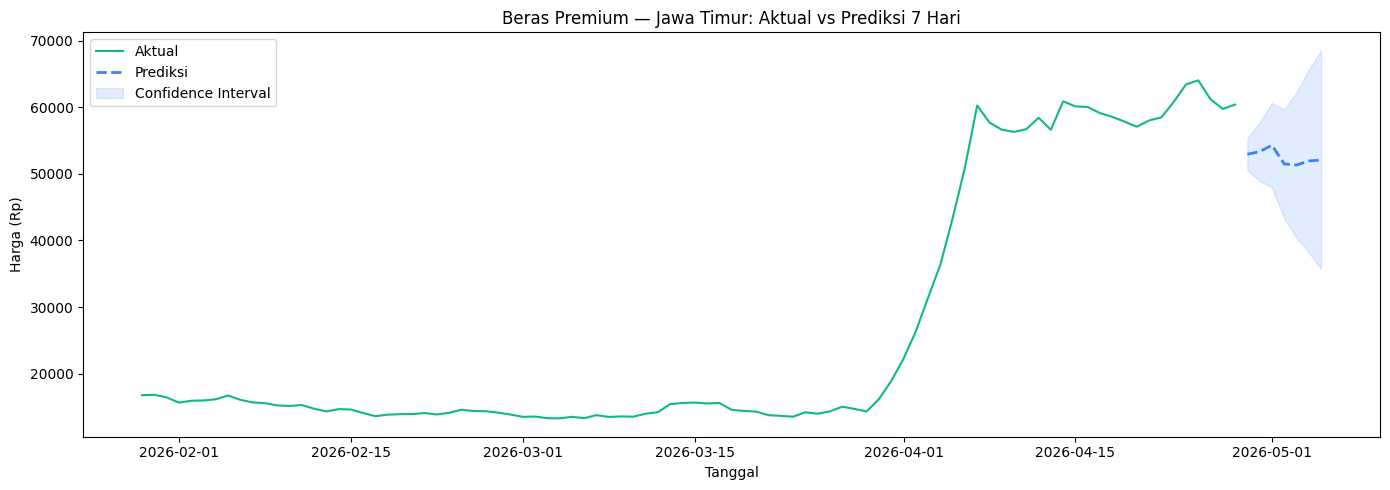

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

# Actual
ax.plot(df_beras['recorded_at'], df_beras['price'], color='#10B981', linewidth=1.5, label='Aktual')

# Predicted
pred_dates = pd.to_datetime([p['date'] for p in forecast['predictions']])
pred_prices = [p['predicted_price'] for p in forecast['predictions']]
pred_lower = [p['lower_bound'] for p in forecast['predictions']]
pred_upper = [p['upper_bound'] for p in forecast['predictions']]

ax.plot(pred_dates, pred_prices, color='#3B82F6', linewidth=2, linestyle='--', label='Prediksi')
ax.fill_between(pred_dates, pred_lower, pred_upper, alpha=0.15, color='#3B82F6', label='Confidence Interval')

ax.set_title('Beras Premium — Jawa Timur: Aktual vs Prediksi 7 Hari')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Harga (Rp)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/price_forecast_visualization.png', dpi=150)
plt.show()

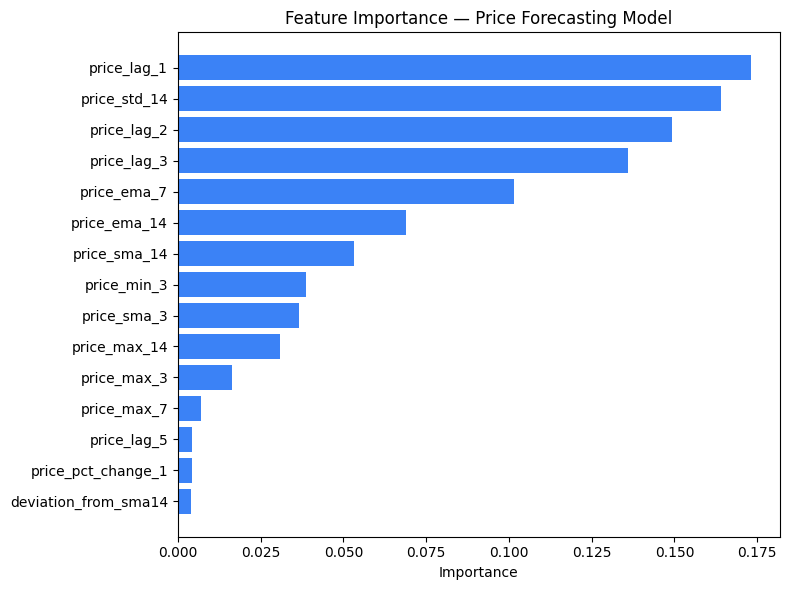

In [10]:
importance = forecaster.get_feature_importance()
imp_df = pd.DataFrame({'feature': importance.keys(), 'importance': importance.values()})
imp_df = imp_df.sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df['feature'], imp_df['importance'], color='#3B82F6')
ax.set_title('Feature Importance — Price Forecasting Model')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


In [11]:
import os
os.makedirs('../models', exist_ok=True)
forecaster.save('../models/price_model.pkl')


Price model saved -> ../models/price_model.pkl
